
# Anomaly Detection

## Credit Risk Intelligence Lab

This notebook adds an anomaly detection layer to the Credit Risk Intelligence Lab.

The previous notebooks built two complementary views of credit risk:

1. A supervised **Probability of Default (PD)** model.
2. An unsupervised **risk segmentation** model.

This notebook asks a third question: **which borrowers look unusual compared with the rest of the portfolio?**

In credit risk, anomaly detection is useful because not every relevant risk signal appears as a high predicted probability of default. Some borrowers may not be classified as high risk by the baseline PD model, but their combination of characteristics can still be unusual enough to deserve review. This notebook therefore treats anomaly detection as a portfolio monitoring tool, not as a direct credit approval rule.



## Notebook objectives

This notebook focuses on seven tasks:

1. Load processed borrower features, raw borrower variables, PD predictions, and risk clusters.
2. Fit anomaly detection models using processed borrower features.
3. Compare Isolation Forest and Local Outlier Factor.
4. Create an ensemble anomaly score.
5. Identify borrowers with unusual credit profiles.
6. Compare anomalous borrowers against the full portfolio by PD, exposure, expected loss, and cluster membership.
7. Save anomaly labels, summary tables, visualizations, and model artifacts.

The output of this notebook complements both the supervised PD model and the unsupervised segmentation layer.


In [1]:

from pathlib import Path
import warnings
import pickle
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")



## Project paths

The notebook is designed to run either from the project root or from the `notebooks/` directory.


In [2]:

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_FIGURES = PROJECT_ROOT / "reports" / "figures"
REPORTS_TABLES = PROJECT_ROOT / "reports" / "tables"

for path in [DATA_PROCESSED, MODELS_DIR, REPORTS_FIGURES, REPORTS_TABLES]:
    path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data path: {DATA_PROCESSED}")
print(f"Models path: {MODELS_DIR}")
print(f"Figures path: {REPORTS_FIGURES}")
print(f"Tables path: {REPORTS_TABLES}")


Project root: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab
Processed data path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/data/processed
Models path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/models
Figures path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/reports/figures
Tables path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/reports/tables



## Load processed data and previous model outputs

This notebook expects outputs from notebooks 02, 03, and 04.

Required files:

```text
data/processed/X_train_processed.csv
data/processed/X_test_processed.csv
data/processed/X_train.csv
data/processed/X_test.csv
data/processed/y_train.csv
data/processed/y_test.csv
data/processed/test_pd_predictions.csv
data/processed/risk_cluster_assignments.csv
```

The anomaly models use the processed feature matrix. The raw variables, PD predictions, and cluster labels are used later to interpret the anomalous profiles.


In [3]:

required_files = {
    "X_train_processed": DATA_PROCESSED / "X_train_processed.csv",
    "X_test_processed": DATA_PROCESSED / "X_test_processed.csv",
    "X_train_raw": DATA_PROCESSED / "X_train.csv",
    "X_test_raw": DATA_PROCESSED / "X_test.csv",
    "y_train": DATA_PROCESSED / "y_train.csv",
    "y_test": DATA_PROCESSED / "y_test.csv",
    "pd_predictions": DATA_PROCESSED / "test_pd_predictions.csv",
    "cluster_assignments": DATA_PROCESSED / "risk_cluster_assignments.csv",
}

missing_files = [name for name, path in required_files.items() if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Missing files: "
        + ", ".join(missing_files)
        + ". Run notebooks 02, 03, and 04 before this notebook."
    )

X_train_processed = pd.read_csv(required_files["X_train_processed"], index_col=0)
X_test_processed = pd.read_csv(required_files["X_test_processed"], index_col=0)

X_train_raw = pd.read_csv(required_files["X_train_raw"], index_col=0)
X_test_raw = pd.read_csv(required_files["X_test_raw"], index_col=0)

y_train = pd.read_csv(required_files["y_train"], index_col=0).iloc[:, 0]
y_test = pd.read_csv(required_files["y_test"], index_col=0).iloc[:, 0]

pd_predictions = pd.read_csv(required_files["pd_predictions"], index_col=0)
cluster_assignments = pd.read_csv(required_files["cluster_assignments"], index_col=0)

print(f"X_train_processed: {X_train_processed.shape}")
print(f"X_test_processed: {X_test_processed.shape}")
print(f"PD predictions: {pd_predictions.shape}")
print(f"Cluster assignments: {cluster_assignments.shape}")


X_train_processed: (800, 79)
X_test_processed: (200, 79)
PD predictions: (200, 9)
Cluster assignments: (1000, 8)



## Build full anomaly detection portfolio

The anomaly detection layer is built on the full analytical portfolio by combining the train and test samples.

For interpretation, we attach:

- Actual default label.
- Supervised predicted PD.
- K-Means risk cluster.
- Exposure proxy.
- Expected loss proxy.


In [4]:

X_processed = pd.concat([X_train_processed, X_test_processed], axis=0)
X_raw = pd.concat([X_train_raw, X_test_raw], axis=0)
y = pd.concat([y_train, y_test], axis=0)

X_processed.index = X_processed.index.astype(str)
X_raw.index = X_raw.index.astype(str)
y.index = y.index.astype(str)
pd_predictions.index = pd_predictions.index.astype(str)
cluster_assignments.index = cluster_assignments.index.astype(str)

portfolio = X_raw.copy()
portfolio["actual_default"] = y

# Attach predicted PD.
# test_pd_predictions.csv contains test predictions only, so training rows may be missing.
# For this anomaly notebook, test rows get supervised PD directly from notebook 03.
if "predicted_pd" in pd_predictions.columns:
    portfolio["predicted_pd"] = pd_predictions["predicted_pd"]
else:
    portfolio["predicted_pd"] = np.nan

# Attach risk cluster from notebook 04.
if "risk_cluster" in cluster_assignments.columns:
    portfolio["risk_cluster"] = cluster_assignments["risk_cluster"]
else:
    portfolio["risk_cluster"] = np.nan

# Fill missing PD values if the full segmentation output contains predicted PD.
segments_file = DATA_PROCESSED / "credit_risk_segments.csv"
if segments_file.exists():
    segments = pd.read_csv(segments_file, index_col=0)
    segments.index = segments.index.astype(str)
    if "predicted_pd" in segments.columns:
        portfolio["predicted_pd"] = portfolio["predicted_pd"].fillna(segments["predicted_pd"])
    if "risk_cluster" in segments.columns:
        portfolio["risk_cluster"] = portfolio["risk_cluster"].fillna(segments["risk_cluster"])

# Exposure and expected loss proxy.
LGD_ASSUMPTION = 0.45

portfolio["ead_proxy"] = portfolio["credit_amount"]
portfolio["expected_loss_proxy"] = (
    portfolio["predicted_pd"]
    * LGD_ASSUMPTION
    * portfolio["ead_proxy"]
)

print(f"Full processed matrix: {X_processed.shape}")
print(f"Full interpretation portfolio: {portfolio.shape}")

portfolio.head()


Full processed matrix: (1000, 79)
Full interpretation portfolio: (1000, 34)


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct_income,personal_status_sex,other_debtors_guarantors,present_residence_since,property,age_years,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,credit_amount_per_month,credit_amount_log,duration_years,long_duration_flag,high_credit_amount_flag,installment_burden_proxy,age_bucket,duration_bucket,credit_amount_bucket,actual_default,predicted_pd,risk_cluster,ead_proxy,expected_loss_proxy
828,A11,36,A32,A41,8335,A65,A75,3,A93,A101,4,A124,47,A143,A153,1,A173,1,A191,A201,231.5278,9.0283,3.0000,1,1,25005,mid_career,long_term,high_amount,1,0.5487,1,8335,"2,058.0017"
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,4,A123,38,A143,A152,1,A173,1,A191,A201,67.0000,6.6908,1.0000,0,0,3216,mid_career,short_term,low_amount,0,0.1170,0,804,42.3423
148,A11,36,A34,A42,5371,A61,A73,3,A93,A103,2,A122,28,A143,A152,2,A173,1,A191,A201,149.1944,8.5890,3.0000,1,1,16113,early_career,long_term,high_amount,0,0.6783,1,5371,"1,639.4020"
735,A12,36,A31,A44,3990,A65,A72,3,A92,A101,2,A124,29,A141,A152,1,A171,1,A191,A201,110.8333,8.2918,3.0000,1,1,11970,early_career,long_term,high_amount,0,0.9167,1,3990,"1,645.9621"
130,A12,48,A32,A40,8487,A65,A74,1,A92,A101,2,A123,24,A143,A152,1,A173,1,A191,A201,176.8125,9.0464,4.0000,1,1,8487,young,very_long_term,high_amount,0,0.5706,1,8487,"2,179.1908"



## Anomaly detection design

Anomaly detection does not use the default label during model fitting. It searches for unusual observations based on feature structure.

This notebook uses two methods:

1. **Isolation Forest**: isolates observations through random splits. More isolated observations are considered more anomalous.
2. **Local Outlier Factor**: compares each borrower with local neighbors. Borrowers in sparse local regions are considered more anomalous.

The final score is an ensemble of both methods after normalizing their anomaly scores to a 0-1 scale.

A higher anomaly score means a borrower is more unusual relative to the rest of the portfolio.



## Fit Isolation Forest

The contamination rate is the expected share of anomalies. Here we use 5% as an analytical starting point. This is not a business rule; it is a modeling assumption for the first version.


In [5]:

CONTAMINATION = 0.05
RANDOM_STATE = 42

isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

isolation_forest.fit(X_processed)

# IsolationForest returns higher decision_function values for more normal observations.
# We multiply by -1 so that higher values mean more anomalous.
if_raw_score = -isolation_forest.decision_function(X_processed)
if_label = isolation_forest.predict(X_processed)

# Convert labels from {-1, 1} to {1, 0}; 1 means anomaly.
if_anomaly_flag = np.where(if_label == -1, 1, 0)

portfolio["if_raw_score"] = if_raw_score
portfolio["if_anomaly_flag"] = if_anomaly_flag

portfolio["if_anomaly_flag"].value_counts()


if_anomaly_flag
0    950
1     50
Name: count, dtype: int64


## Fit Local Outlier Factor

Local Outlier Factor is sensitive to neighborhood structure. It is useful for identifying borrowers that are unusual relative to nearby borrowers, not only globally unusual.

We use `novelty=False` because this notebook analyzes the existing portfolio rather than scoring future new borrowers.


In [6]:

lof_model = LocalOutlierFactor(
    n_neighbors=35,
    contamination=CONTAMINATION,
    novelty=False,
)

lof_label = lof_model.fit_predict(X_processed)

# negative_outlier_factor_ is more negative for stronger outliers.
# We multiply by -1 so that higher values mean more anomalous.
lof_raw_score = -lof_model.negative_outlier_factor_
lof_anomaly_flag = np.where(lof_label == -1, 1, 0)

portfolio["lof_raw_score"] = lof_raw_score
portfolio["lof_anomaly_flag"] = lof_anomaly_flag

portfolio["lof_anomaly_flag"].value_counts()


lof_anomaly_flag
0    950
1     50
Name: count, dtype: int64


## Build ensemble anomaly score

Because different anomaly detection models capture different structures, we create a simple ensemble score.

The process is:

1. Normalize the Isolation Forest raw score to a 0-1 range.
2. Normalize the LOF raw score to a 0-1 range.
3. Average both normalized scores.
4. Flag the top 5% highest ensemble scores as final anomalies.


In [7]:

score_scaler = MinMaxScaler()

score_matrix = portfolio[["if_raw_score", "lof_raw_score"]].copy()
score_matrix_scaled = score_scaler.fit_transform(score_matrix)

portfolio["if_score_scaled"] = score_matrix_scaled[:, 0]
portfolio["lof_score_scaled"] = score_matrix_scaled[:, 1]
portfolio["ensemble_anomaly_score"] = (
    portfolio["if_score_scaled"] + portfolio["lof_score_scaled"]
) / 2

anomaly_threshold = portfolio["ensemble_anomaly_score"].quantile(1 - CONTAMINATION)

portfolio["ensemble_anomaly_flag"] = np.where(
    portfolio["ensemble_anomaly_score"] >= anomaly_threshold,
    1,
    0,
)

portfolio[[
    "if_score_scaled",
    "lof_score_scaled",
    "ensemble_anomaly_score",
    "ensemble_anomaly_flag",
]].head()


,if_score_scaled,lof_score_scaled,ensemble_anomaly_score,ensemble_anomaly_flag
828,0.4163,0.0128,0.2145,0
997,0.0002,0.0017,0.0010,0
148,0.3777,0.0048,0.1913,0
735,0.7040,0.0174,0.3607,1
130,0.4376,0.0145,0.2260,0


In [8]:

anomaly_flag_summary = pd.DataFrame(
    {
        "method": ["Isolation Forest", "Local Outlier Factor", "Ensemble"],
        "anomaly_count": [
            int(portfolio["if_anomaly_flag"].sum()),
            int(portfolio["lof_anomaly_flag"].sum()),
            int(portfolio["ensemble_anomaly_flag"].sum()),
        ],
        "anomaly_rate": [
            portfolio["if_anomaly_flag"].mean(),
            portfolio["lof_anomaly_flag"].mean(),
            portfolio["ensemble_anomaly_flag"].mean(),
        ],
    }
)

anomaly_flag_summary


,method,anomaly_count,anomaly_rate
0,Isolation Forest,50,0.0500
1,Local Outlier Factor,50,0.0500
2,Ensemble,50,0.0500



## Visualize anomaly scores

The distribution of anomaly scores helps identify whether the top anomalous borrowers are clearly separated or whether anomaly intensity changes gradually across the portfolio.


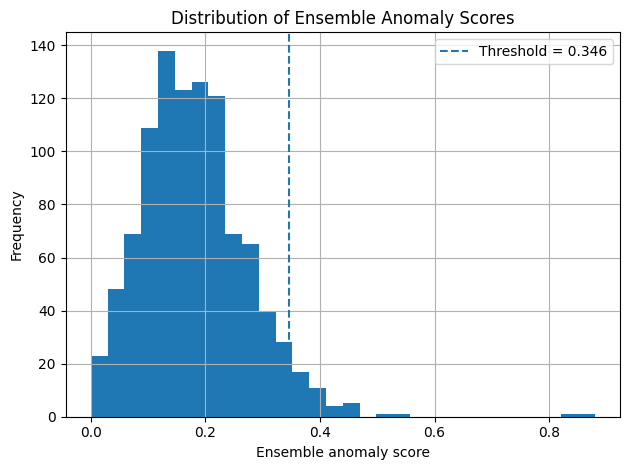

In [9]:

fig, ax = plt.subplots()

portfolio["ensemble_anomaly_score"].hist(bins=30, ax=ax)
ax.axvline(anomaly_threshold, linestyle="--", label=f"Threshold = {anomaly_threshold:.3f}")

ax.set_title("Distribution of Ensemble Anomaly Scores")
ax.set_xlabel("Ensemble anomaly score")
ax.set_ylabel("Frequency")
ax.legend()

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "05_ensemble_anomaly_score_distribution.png", dpi=150)
plt.show();



## PCA visualization of anomalies

The chart below projects borrowers into two principal components and highlights final ensemble anomalies.

The anomaly models were fitted on the full processed feature matrix. PCA is used only for visualization.


In [10]:

pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_processed)

pca_df = pd.DataFrame(
    pca_components,
    columns=["PC1", "PC2"],
    index=X_processed.index,
)

pca_df["ensemble_anomaly_flag"] = portfolio["ensemble_anomaly_flag"]
pca_df["ensemble_anomaly_score"] = portfolio["ensemble_anomaly_score"]

print(f"PC1 explained variance: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2 explained variance: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.4f}")


PC1 explained variance: 0.2571
PC2 explained variance: 0.1139
Total explained variance: 0.3709


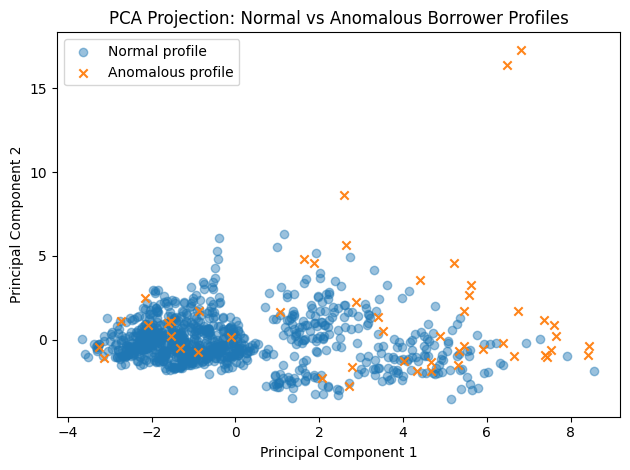

In [11]:

fig, ax = plt.subplots()

normal_points = pca_df[pca_df["ensemble_anomaly_flag"] == 0]
anomaly_points = pca_df[pca_df["ensemble_anomaly_flag"] == 1]

ax.scatter(
    normal_points["PC1"],
    normal_points["PC2"],
    alpha=0.45,
    label="Normal profile",
)

ax.scatter(
    anomaly_points["PC1"],
    anomaly_points["PC2"],
    alpha=0.95,
    marker="x",
    label="Anomalous profile",
)

ax.set_title("PCA Projection: Normal vs Anomalous Borrower Profiles")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend()

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "05_pca_anomaly_projection.png", dpi=150)
plt.show();



## Portfolio comparison: anomalies vs normal borrowers

Anomalies should be interpreted carefully. An anomalous borrower is not automatically a bad borrower. The borrower is simply unusual relative to the feature structure of the portfolio.

This section compares anomalous and normal profiles using credit risk variables.


In [12]:

anomaly_comparison = (
    portfolio
    .groupby("ensemble_anomaly_flag")
    .agg(
        borrowers=("actual_default", "size"),
        observed_default_rate=("actual_default", "mean"),
        avg_predicted_pd=("predicted_pd", "mean"),
        median_predicted_pd=("predicted_pd", "median"),
        avg_credit_amount=("credit_amount", "mean"),
        total_exposure_proxy=("ead_proxy", "sum"),
        total_expected_loss_proxy=("expected_loss_proxy", "sum"),
        avg_duration_months=("duration_months", "mean"),
        avg_age=("age_years", "mean"),
        avg_installment_rate=("installment_rate_pct_income", "mean"),
        avg_ensemble_anomaly_score=("ensemble_anomaly_score", "mean"),
    )
    .assign(
        portfolio_share=lambda x: x["borrowers"] / len(portfolio),
        exposure_share=lambda x: x["total_exposure_proxy"] / x["total_exposure_proxy"].sum(),
        expected_loss_share=lambda x: x["total_expected_loss_proxy"] / x["total_expected_loss_proxy"].sum(),
    )
)

anomaly_comparison.index = ["normal_profile", "anomalous_profile"] # type: ignore
anomaly_comparison


,borrowers,observed_default_rate,avg_predicted_pd,median_predicted_pd,avg_credit_amount,total_exposure_proxy,total_expected_loss_proxy,avg_duration_months,avg_age,avg_installment_rate,avg_ensemble_anomaly_score,portfolio_share,exposure_share,expected_loss_share
normal_profile,950,0.2895,0.4194,0.3897,"3,017.8442",2866952,"600,467.2153",20.4453,35.1642,2.9937,0.1701,0.9500,0.8764,0.8195
anomalous_profile,50,0.5000,0.6684,0.7249,"8,086.1200",404306,"132,280.1344",29.6000,42.8000,2.5800,0.4077,0.0500,0.1236,0.1805


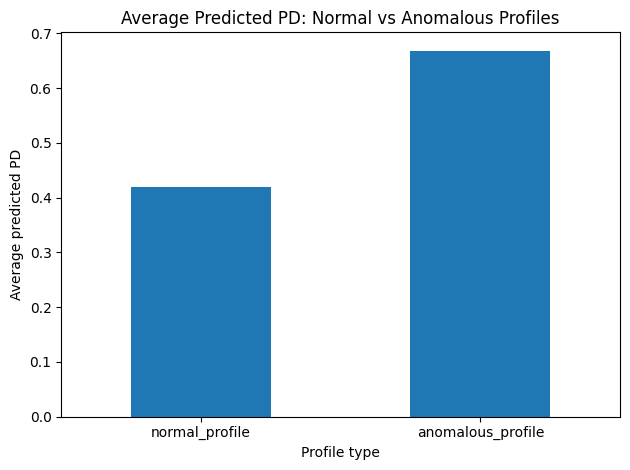

In [13]:

fig, ax = plt.subplots()

anomaly_comparison["avg_predicted_pd"].plot(kind="bar", ax=ax)

ax.set_title("Average Predicted PD: Normal vs Anomalous Profiles")
ax.set_xlabel("Profile type")
ax.set_ylabel("Average predicted PD")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "05_average_pd_anomaly_comparison.png", dpi=150)
plt.show();


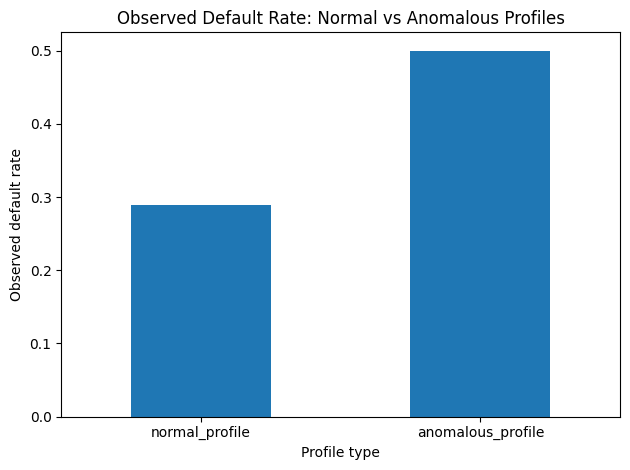

In [14]:

fig, ax = plt.subplots()

anomaly_comparison["observed_default_rate"].plot(kind="bar", ax=ax)

ax.set_title("Observed Default Rate: Normal vs Anomalous Profiles")
ax.set_xlabel("Profile type")
ax.set_ylabel("Observed default rate")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "05_observed_default_rate_anomaly_comparison.png", dpi=150)
plt.show();



## Anomalies by risk cluster

This section connects anomaly detection with the unsupervised segmentation from notebook 04.

A cluster with a high anomaly rate may contain more heterogeneous or structurally unusual borrower profiles.


In [15]:

cluster_anomaly_summary = (
    portfolio
    .groupby("risk_cluster")
    .agg(
        borrowers=("ensemble_anomaly_flag", "size"),
        anomalies=("ensemble_anomaly_flag", "sum"),
        anomaly_rate=("ensemble_anomaly_flag", "mean"),
        avg_predicted_pd=("predicted_pd", "mean"),
        observed_default_rate=("actual_default", "mean"),
        total_expected_loss_proxy=("expected_loss_proxy", "sum"),
    )
    .assign(
        anomaly_share=lambda x: x["anomalies"] / x["anomalies"].sum()
    )
    .sort_values("anomaly_rate", ascending=False)
)

cluster_anomaly_summary


,borrowers,anomalies,anomaly_rate,avg_predicted_pd,observed_default_rate,total_expected_loss_proxy,anomaly_share
risk_cluster,,,,,,,
1,282,38,0.1348,0.5624,0.4255,"508,266.5752",0.7600
0,718,12,0.0167,0.3806,0.2507,"224,480.7744",0.2400


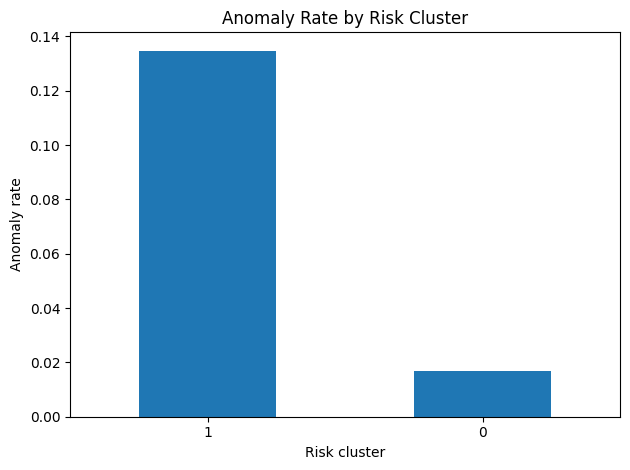

In [16]:

fig, ax = plt.subplots()

cluster_anomaly_summary["anomaly_rate"].plot(kind="bar", ax=ax)

ax.set_title("Anomaly Rate by Risk Cluster")
ax.set_xlabel("Risk cluster")
ax.set_ylabel("Anomaly rate")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "05_anomaly_rate_by_cluster.png", dpi=150)
plt.show();



## Top anomalous borrowers

This table ranks borrowers by ensemble anomaly score.

The purpose is not to create an automatic rejection list. The purpose is to identify profiles that deserve analytical review because their feature combinations are unusual.


In [17]:

top_anomalies = (
    portfolio
    .sort_values("ensemble_anomaly_score", ascending=False)
    .head(20)
)

selected_review_columns = [
    "ensemble_anomaly_score",
    "if_score_scaled",
    "lof_score_scaled",
    "ensemble_anomaly_flag",
    "actual_default",
    "predicted_pd",
    "risk_cluster",
    "credit_amount",
    "duration_months",
    "age_years",
    "installment_rate_pct_income",
    "existing_credits",
    "people_liable",
    "ead_proxy",
    "expected_loss_proxy",
]

available_review_columns = [
    col for col in selected_review_columns if col in top_anomalies.columns
]

top_anomalies[available_review_columns]


,ensemble_anomaly_score,if_score_scaled,lof_score_scaled,ensemble_anomaly_flag,actual_default,predicted_pd,risk_cluster,credit_amount,duration_months,age_years,installment_rate_pct_income,existing_credits,people_liable,ead_proxy,expected_loss_proxy
917,0.8795,0.7591,1.0000,1,1,0.9985,1,14896,6,68,1,1,1,14896,"6,692.8696"
236,0.8353,0.7125,0.9582,1,1,0.9573,1,14555,6,23,1,1,1,14555,"6,270.3416"
374,0.5432,1.0000,0.0864,1,1,0.9752,1,14782,60,60,3,2,1,14782,"6,487.1436"
272,0.4988,0.9493,0.0483,1,0,0.9096,1,12169,48,36,4,1,1,12169,"4,981.0429"
915,0.4656,0.8425,0.0887,1,1,0.6485,1,18424,48,32,1,1,1,18424,"5,376.9306"
186,0.4500,0.7970,0.1030,1,1,0.7940,1,5129,9,74,2,1,2,5129,"1,832.4826"
774,0.4489,0.8083,0.0895,1,0,0.3986,0,1480,12,66,2,3,1,1480,265.4995
818,0.4431,0.8245,0.0617,1,0,0.9567,1,15857,36,43,2,1,1,15857,"6,826.7076"
889,0.4418,0.8277,0.0559,1,0,0.3159,1,7824,28,40,3,2,2,7824,"1,112.2200"
95,0.4313,0.7866,0.0759,1,1,0.9893,1,15945,54,58,3,1,1,15945,"7,098.1684"



## Anomaly profile explanation helper

The helper below generates a simple rule-based explanation for why a borrower may look unusual. It compares the borrower against portfolio-level percentiles.

This is not a substitute for SHAP or full local explainability. It is an interpretable diagnostic layer that helps translate anomaly scores into readable risk notes.


In [18]:

numeric_explanation_features = [
    "credit_amount",
    "duration_months",
    "age_years",
    "installment_rate_pct_income",
    "existing_credits",
    "people_liable",
]

available_numeric_explanation_features = [
    col for col in numeric_explanation_features if col in portfolio.columns
]

percentile_table = portfolio[available_numeric_explanation_features].quantile([0.05, 0.25, 0.75, 0.95])

def explain_anomaly_profile(row):
    notes = []

    for feature in available_numeric_explanation_features:
        value = row[feature]
        p05 = percentile_table.loc[0.05, feature]
        p25 = percentile_table.loc[0.25, feature]
        p75 = percentile_table.loc[0.75, feature]
        p95 = percentile_table.loc[0.95, feature]

        if value >= p95:
            notes.append(f"{feature} is extremely high")
        elif value >= p75:
            notes.append(f"{feature} is high")
        elif value <= p05:
            notes.append(f"{feature} is extremely low")
        elif value <= p25:
            notes.append(f"{feature} is low")

    if row.get("predicted_pd", np.nan) >= portfolio["predicted_pd"].quantile(0.75):
        notes.append("predicted PD is high")
    elif row.get("predicted_pd", np.nan) <= portfolio["predicted_pd"].quantile(0.25):
        notes.append("predicted PD is low")

    if not notes:
        notes.append("unusual multivariate combination not explained by simple univariate thresholds")

    return "; ".join(notes)

top_anomaly_explanations = top_anomalies.copy()
top_anomaly_explanations["anomaly_review_notes"] = top_anomaly_explanations.apply(
    explain_anomaly_profile,
    axis=1,
)

top_anomaly_explanations[
    available_review_columns + ["anomaly_review_notes"]
].head(10)


,ensemble_anomaly_score,if_score_scaled,lof_score_scaled,ensemble_anomaly_flag,actual_default,predicted_pd,risk_cluster,credit_amount,duration_months,age_years,installment_rate_pct_income,existing_credits,people_liable,ead_proxy,expected_loss_proxy,anomaly_review_notes
917,0.8795,0.7591,1.0000,1,1,0.9985,1,14896,6,68,1,1,1,14896,"6,692.8696",credit_amount is extremely high; duration_mont...
236,0.8353,0.7125,0.9582,1,1,0.9573,1,14555,6,23,1,1,1,14555,"6,270.3416",credit_amount is extremely high; duration_mont...
374,0.5432,1.0000,0.0864,1,1,0.9752,1,14782,60,60,3,2,1,14782,"6,487.1436",credit_amount is extremely high; duration_mont...
272,0.4988,0.9493,0.0483,1,0,0.9096,1,12169,48,36,4,1,1,12169,"4,981.0429",credit_amount is extremely high; duration_mont...
915,0.4656,0.8425,0.0887,1,1,0.6485,1,18424,48,32,1,1,1,18424,"5,376.9306",credit_amount is extremely high; duration_mont...
186,0.4500,0.7970,0.1030,1,1,0.7940,1,5129,9,74,2,1,2,5129,"1,832.4826",credit_amount is high; duration_months is low;...
774,0.4489,0.8083,0.0895,1,0,0.3986,0,1480,12,66,2,3,1,1480,265.4995,duration_months is low; age_years is extremely...
818,0.4431,0.8245,0.0617,1,0,0.9567,1,15857,36,43,2,1,1,15857,"6,826.7076",credit_amount is extremely high; duration_mont...
889,0.4418,0.8277,0.0559,1,0,0.3159,1,7824,28,40,3,2,2,7824,"1,112.2200",credit_amount is high; duration_months is high...
95,0.4313,0.7866,0.0759,1,1,0.9893,1,15945,54,58,3,1,1,15945,"7,098.1684",credit_amount is extremely high; duration_mont...



## Relationship between anomaly score and predicted PD

A useful diagnostic is whether anomaly score and predicted PD are strongly related or whether they capture different information.

If anomaly score and PD are not perfectly aligned, the anomaly layer provides complementary portfolio intelligence.


In [19]:

correlation_anomaly_pd = portfolio[["ensemble_anomaly_score", "predicted_pd"]].corr().iloc[0, 1]

print(f"Correlation between ensemble anomaly score and predicted PD: {correlation_anomaly_pd:.4f}")


Correlation between ensemble anomaly score and predicted PD: 0.2844


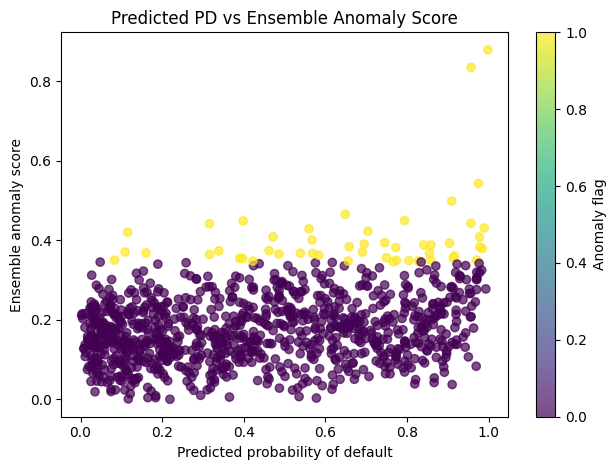

In [20]:

fig, ax = plt.subplots()

scatter = ax.scatter(
    portfolio["predicted_pd"],
    portfolio["ensemble_anomaly_score"],
    c=portfolio["ensemble_anomaly_flag"],
    alpha=0.70,
)

ax.set_title("Predicted PD vs Ensemble Anomaly Score")
ax.set_xlabel("Predicted probability of default")
ax.set_ylabel("Ensemble anomaly score")

fig.colorbar(scatter, ax=ax, label="Anomaly flag")
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "05_pd_vs_anomaly_score.png", dpi=150)
plt.show();



## Save anomaly detection artifacts

This section saves anomaly labels, scores, summary tables, figures, and model artifacts.

The Local Outlier Factor model is not saved as a future scoring model because it was fitted with `novelty=False`. For production-style scoring of new borrowers, a different LOF configuration or a separate outlier scoring design would be needed.


In [21]:

anomaly_output_columns = [
    "actual_default",
    "predicted_pd",
    "risk_cluster",
    "credit_amount",
    "duration_months",
    "age_years",
    "ead_proxy",
    "expected_loss_proxy",
    "if_score_scaled",
    "lof_score_scaled",
    "ensemble_anomaly_score",
    "if_anomaly_flag",
    "lof_anomaly_flag",
    "ensemble_anomaly_flag",
]

available_anomaly_output_columns = [
    col for col in anomaly_output_columns if col in portfolio.columns
]

anomaly_scores_output = portfolio[available_anomaly_output_columns].copy()
anomaly_scores_output.to_csv(DATA_PROCESSED / "credit_risk_anomaly_scores.csv", index=True)

top_anomaly_explanations[
    available_review_columns + ["anomaly_review_notes"]
].to_csv(REPORTS_TABLES / "05_top_anomaly_review.csv", index=True)

anomaly_flag_summary.to_csv(REPORTS_TABLES / "05_anomaly_flag_summary.csv", index=False)
anomaly_comparison.to_csv(REPORTS_TABLES / "05_anomaly_comparison.csv", index=True)
cluster_anomaly_summary.to_csv(REPORTS_TABLES / "05_cluster_anomaly_summary.csv", index=True)

with open(MODELS_DIR / "isolation_forest_anomaly_model.pkl", "wb") as f:
    pickle.dump(isolation_forest, f)

with open(MODELS_DIR / "anomaly_score_scaler.pkl", "wb") as f:
    pickle.dump(score_scaler, f)

with open(MODELS_DIR / "pca_anomaly_projection.pkl", "wb") as f:
    pickle.dump(pca, f)

anomaly_metadata = {
    "model_layer": "anomaly_detection",
    "methods": ["IsolationForest", "LocalOutlierFactor", "ensemble_average"],
    "contamination": CONTAMINATION,
    "ensemble_threshold": float(anomaly_threshold),
    "n_observations": int(len(portfolio)),
    "n_processed_features": int(X_processed.shape[1]),
    "n_ensemble_anomalies": int(portfolio["ensemble_anomaly_flag"].sum()),
    "ensemble_anomaly_rate": float(portfolio["ensemble_anomaly_flag"].mean()),
    "correlation_anomaly_score_predicted_pd": float(correlation_anomaly_pd),
    "lgd_assumption": LGD_ASSUMPTION,
}

with open(MODELS_DIR / "anomaly_detection_metadata.json", "w") as f:
    json.dump(anomaly_metadata, f, indent=4)

print("Saved anomaly scores, summary tables, model artifacts, and metadata.")


Saved anomaly scores, summary tables, model artifacts, and metadata.



## Analytical conclusions

This notebook added an anomaly detection layer to the Credit Risk Intelligence Lab.

The main contribution is that the project now has three complementary views of credit risk:

1. **Supervised PD model**: estimates borrower-level probability of default.
2. **Unsupervised risk segmentation**: groups borrowers into hidden portfolio segments.
3. **Anomaly detection**: identifies unusual borrower profiles that may deserve review.

Key outputs:

- Isolation Forest anomaly scores.
- Local Outlier Factor anomaly scores.
- Ensemble anomaly score and final anomaly flag.
- PCA visualization of anomalous borrower profiles.
- Comparison of normal and anomalous borrowers.
- Anomaly rate by risk cluster.
- Ranked review table of top anomalous profiles.
- Saved anomaly detection artifacts for future reporting.

The next notebook should focus on model interpretability:

```text
notebooks/06_model_interpretability.ipynb
```

That stage should explain the supervised PD model more deeply through coefficients, feature importance, and local borrower-level explanations.
